<a href="https://colab.research.google.com/github/seowon-rhee/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_4%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 오픈소스 기반 데이터 분석 4강 - 데이터 수집


## 4-1 CSV 파일 읽기

In [ ]:
import pandas as pd

## data.csv 파일 읽기
df = pd.read_csv('data.csv', encoding='utf-8', sep=',', header=0, index_col=None,skiprows=None,nrows=None)
print(df)

           날짜    체중  골격근량  체지방량
0  2025.02.06  64.7  30.0  11.1
1  2025.02.04  64.0  29.3  11.6


## 4-2 JSON 파일 읽기



In [ ]:
import json
import pandas as pd

## data.json 파일 출력
with open('data.json', mode='r', encoding='utf-8') as f:
  data = json.load(f)
print(data)

## data.json 파일 DataFrame 읽기
df = pd.read_json('data.json', orient='records',encoding='utf-8',lines=False)

print(df)

{'매출데이터': [{'월': '2025-01', '매출액': 1000000, '비용': 700000, '이익': 300000}, {'월': '2025-02', '매출액': 1200000, '비용': 800000, '이익': 400000}, {'월': '2025-03', '매출액': 1500000, '비용': 900000, '이익': 600000}]}
                                               매출데이터
0  {'월': '2025-01', '매출액': 1000000, '비용': 700000,...
1  {'월': '2025-02', '매출액': 1200000, '비용': 800000,...
2  {'월': '2025-03', '매출액': 1500000, '비용': 900000,...


## 4-3 텍스트 파일 읽기 및 데이터 추출

In [ ]:
import re

## 파일(callcenter20250301.log) 오픈 및 읽기
with open('callcenter20250301.log', 'r', encoding='utf-8') as f:
    content = f.read()
## 주민등록번호 패턴 생성
pattern = re.compile(r'(\d{6})-(\d{7})')

## 주민등록번호 마스킹
masked_content = pattern.sub(r'\1-*******',content)

## 마스킹된 파일(callcenter20250301_masked.log) 오픈 및 쓰기
with open('callcenter20250301_masked.log', mode='w') as f:
  f.write(masked_content)

print("주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.")

주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.


## 4-4 Open-Meteo의 무료 날씨 API를 통한 특정 지역 온도 조회

In [ ]:
import requests
import json

url = "https://api.open-meteo.com/v1/forecast?=&=&current=temperature_2m"
params = {
    "latitude": "37.58638333",
    "longitude": "127.0203333",
    "current": "temperature_2m"
}

try:
    ## URL 및 파라미터 전송
    response = requests.get(url, params=params)
    response.raise_for_status()
    ## JSON 데이터 읽기
    data = response.json()

    print("API 응답:", data)
    print("서울시 종로구의 현재 온도는 : {0}{1} 입니다.".format(data['current']['temperature_2m'], data['current_units']['temperature_2m']))

except requests.exceptions.RequestException as e:
    print(f"API 호출 실패: {e}")
except json.JSONDecodeError as e:
    print(f"JSON 파싱 실패: {e}")

API 응답: {'latitude': 37.6, 'longitude': 127.0, 'generationtime_ms': 0.07367134094238281, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 29.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C'}, 'current': {'time': '2026-10-04T06:30', 'interval': 900, 'temperature_2m': 23.2}}
서울시 종로구의 현재 온도는 : 23.2°C 입니다.


## 4-5 Selenium과 lxml을 이용한 웹 스크래핑

In [ ]:
!curl -o google-chrome-stable_current_amd64.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install ./google-chrome-stable_current_amd64.deb -y
!pip install selenium webdriver_manager

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  135M  100  135M    0     0   268M      0 --:--:-- --:--:-- --:--:--  268M
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of './google-chrome-stable_current_amd64.deb'
The following additional packages will be installed:
  at-spi2-common at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0t64
  libatk1.0-0t64 libatspi2.0-0t64 libxcomposite1 libxtst6 session-migration
The following NEW packages will be installed:
  at-spi2-common at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0t64 libatk1.0-0t64 libatspi2.0-0t64 libxcomposite1
  libxtst6 session-migration
0 upgraded, 10 newly installed, 0 to remove and 0 not upgraded.
Need to get 331 kB/143 MB of archives.
After this operation, 459 MB of addition

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from lxml import html
import time

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')               # 브라우저 창 없이 실행
chrome_options.add_argument('--no-sandbox')             # 보안모드 비활성화 (Colab 필수)
chrome_options.add_argument('--disable-dev-shm-usage')  # 메모리 부족 방지 (Colab 필수)
chrome_options.add_argument('--window-size=1920x1080')  # 창 크기 설정(가상)
chrome_options.add_argument('--disable-gpu')            # GPU 가속 비활성화 (일부 환경 안정성)
chrome_options.binary_location = "/usr/bin/google-chrome-stable"  # Colab용 크롬 경로 지정

## 드라이버 실행
driver = webdriver.Chrome(options=chrome_options)

## 사이트 접속
url = 'https://professor.knou.ac.kr/jaehwachung/index.do'
driver.get(url)

## 사이트 접속 대기
time.sleep(2)

## 페이지 제목 출력
page_source = driver.page_source
tree = html.fromstring(page_source)

title_text = tree.xpath('//title/text()')
print(title_text)
## 드라이버 종료
driver.quit()

['컴퓨터과학과 정재화 교수']



# 실습 시나리오

## 공공데이터 포털 가입 및 데이터 신청

- [https://www.data.go.kr](https://www.data.go.kr)
- 한국환경공단 에어코리아 대기오염정보 데이터 신청

In [ ]:
import requests

## 데이터 수집 url 및 api key 설정


params = {
    'serviceKey': api_key,
    'returnType': 'json',
    'numOfRows': '100',
    'pageNo': '1',
    'sidoName': '서울',
    'ver': '1.0'
}

## 데이터 수집

## 호출 성공/실패 출력



In [3]:
import requests

service_key = "ce0abb3224a5eb9e86c2e5485b2088ebfdd6367fb387bae38079be2261000920"
url = (
    "https://apis.data.go.kr/B552845/perDay/price"
    f"?serviceKey={service_key}"
    "&pageNo=1"
    "&numOfRows=200"
    "&returnType=JSON"
    "&cond[exmn_ymd::GTE]=20150101"
    "&cond[exmn_ymd::LTE]=20151231"
    "&cond[se_cd::EQ]=02"
    "&cond[ctgry_cd::EQ]=200"
    "&cond[item_cd::EQ]=211"
    "&cond[grd_cd::EQ]=04"
    "&cond[sgg_cd::EQ]=1101"
    "&cond[mrkt_cd::EQ]=0110211"
    "&cond[vrty_cd::EQ]=01"
)

response = requests.get(url)

print("HTTP 상태코드:", response.status_code)
print(response.text[:1000])

data = response.json()
print("totalCount:", data["response"]["body"]["totalCount"])

HTTP 상태코드: 200
{"response":{"body":{"dataType":"JSON","items":{"item":[{"ctgry_cd":"200","ctgry_nm":"채소류","exmn_dd_cnvs_prc":"9000","exmn_dd_prc":"9000","exmn_ymd":"20150512","grd_cd":"04","grd_nm":"상품","item_cd":"211","item_nm":"배추","mrkt_cd":"0110211","mrkt_nm":"가락도매","orgnl_reg_dt":"2015-05-12T13:53:35Z","se_cd":"02","se_nm":"중도매","sgg_cd":"1101","sgg_nm":"서울","unit":"kg(그물망 3포기)","unit_sz":"10","vrty_cd":"01","vrty_nm":"봄"},{"ctgry_cd":"200","ctgry_nm":"채소류","exmn_dd_cnvs_prc":"8000","exmn_dd_prc":"8000","exmn_ymd":"20150513","grd_cd":"04","grd_nm":"상품","item_cd":"211","item_nm":"배추","mrkt_cd":"0110211","mrkt_nm":"가락도매","orgnl_reg_dt":"2015-05-13T13:47:27Z","se_cd":"02","se_nm":"중도매","sgg_cd":"1101","sgg_nm":"서울","unit":"kg(그물망 3포기)","unit_sz":"10","vrty_cd":"01","vrty_nm":"봄"},{"ctgry_cd":"200","ctgry_nm":"채소류","exmn_dd_cnvs_prc":"8000","exmn_dd_prc":"8000","exmn_ymd":"20150514","grd_cd":"04","grd_nm":"상품","item_cd":"211","item_nm":"배추","mrkt_cd":"0110211","mrkt_nm":"가락도매","orgnl_

In [4]:
all_data = []

varieties = {
    "01": "봄배추",
    "02": "여름배추(고랭지)",
    "03": "가을배추",
    "06": "월동배추"
}

for year in range(2015, 2025):
    for variety_code, variety_name in varieties.items():

        url = (
            "https://apis.data.go.kr/B552845/perDay/price"
            f"?serviceKey={service_key}"
            "&pageNo=1"
            "&numOfRows=200"
            "&returnType=JSON"
            f"&cond[exmn_ymd::GTE]={year}0101"
            f"&cond[exmn_ymd::LTE]={year}1231"
            "&cond[se_cd::EQ]=02"
            "&cond[ctgry_cd::EQ]=200"
            "&cond[item_cd::EQ]=211"
            "&cond[grd_cd::EQ]=04"
            "&cond[sgg_cd::EQ]=1101"
            "&cond[mrkt_cd::EQ]=0110211"
            f"&cond[vrty_cd::EQ]={variety_code}"
        )

        response = requests.get(url)
        data = response.json()

        items = data["response"]["body"]["items"]["item"]

        if isinstance(items, dict):
            items = [items]

        all_data.extend(items)

        print(year, variety_name,
              "상태코드:", response.status_code,
              "수집건수:", len(items))

print("전체 수집 건수:", len(all_data))

2015 봄배추 상태코드: 200 수집건수: 66
2015 여름배추(고랭지) 상태코드: 200 수집건수: 64
2015 가을배추 상태코드: 200 수집건수: 45
2015 월동배추 상태코드: 200 수집건수: 97
2016 봄배추 상태코드: 200 수집건수: 70
2016 여름배추(고랭지) 상태코드: 200 수집건수: 72
2016 가을배추 상태코드: 200 수집건수: 48
2016 월동배추 상태코드: 200 수집건수: 87
2017 봄배추 상태코드: 200 수집건수: 67
2017 여름배추(고랭지) 상태코드: 200 수집건수: 57
2017 가을배추 상태코드: 200 수집건수: 48
2017 월동배추 상태코드: 200 수집건수: 86
2018 봄배추 상태코드: 200 수집건수: 48
2018 여름배추(고랭지) 상태코드: 200 수집건수: 74
2018 가을배추 상태코드: 200 수집건수: 48
2018 월동배추 상태코드: 200 수집건수: 94
2019 봄배추 상태코드: 200 수집건수: 43
2019 여름배추(고랭지) 상태코드: 200 수집건수: 65
2019 가을배추 상태코드: 200 수집건수: 53
2019 월동배추 상태코드: 200 수집건수: 97
2020 봄배추 상태코드: 200 수집건수: 51
2020 여름배추(고랭지) 상태코드: 200 수집건수: 66
2020 가을배추 상태코드: 200 수집건수: 64
2020 월동배추 상태코드: 200 수집건수: 101
2021 봄배추 상태코드: 200 수집건수: 46
2021 여름배추(고랭지) 상태코드: 200 수집건수: 74
2021 가을배추 상태코드: 200 수집건수: 31
2021 월동배추 상태코드: 200 수집건수: 105
2022 봄배추 상태코드: 200 수집건수: 39
2022 여름배추(고랭지) 상태코드: 200 수집건수: 86
2022 가을배추 상태코드: 200 수집건수: 40
2022 월동배추 상태코드: 200 수집건수: 91
2023 봄배추 상태코드: 200 수집건수: 48
2023 여름배추(

In [7]:
import pandas as pd

df = pd.DataFrame(all_data)

print(df.head())
print("\n데이터 기본 정보")
df.info()

  ctgry_cd ctgry_nm exmn_dd_cnvs_prc exmn_dd_prc  exmn_ymd grd_cd grd_nm  \
0      200      채소류             9000        9000  20150512     04     상품   
1      200      채소류             8000        8000  20150513     04     상품   
2      200      채소류             8000        8000  20150514     04     상품   
3      200      채소류             8000        8000  20150515     04     상품   
4      200      채소류            10000       10000  20150518     04     상품   

  item_cd item_nm  mrkt_cd mrkt_nm          orgnl_reg_dt se_cd se_nm sgg_cd  \
0     211      배추  0110211    가락도매  2015-05-12T13:53:35Z    02   중도매   1101   
1     211      배추  0110211    가락도매  2015-05-13T13:47:27Z    02   중도매   1101   
2     211      배추  0110211    가락도매  2015-05-18T14:51:22Z    02   중도매   1101   
3     211      배추  0110211    가락도매  2015-05-18T14:57:50Z    02   중도매   1101   
4     211      배추  0110211    가락도매  2015-05-21T11:25:53Z    02   중도매   1101   

  sgg_nm         unit unit_sz vrty_cd vrty_nm  
0     서울  kg(그물망 3포기

In [12]:
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


In [13]:
df["exmn_ymd"] = pd.to_datetime(df["exmn_ymd"])

df["year"] = df["exmn_ymd"].dt.year
df["month"] = df["exmn_ymd"].dt.month

def get_season(month):
    if 3 <= month <= 5:
        return "봄"
    elif 6 <= month <= 8:
        return "여름"
    elif 9 <= month <= 11:
        return "가을"
    else:
        return "겨울"

df["season"] = df["month"].apply(get_season)

print(df[["exmn_ymd", "year", "season"]].head(10))

print("\n계절별 데이터 확인")
print(df.groupby("season")[["exmn_ymd", "year", "season"]].head(2))

    exmn_ymd  year season
0 2015-05-12  2015      봄
1 2015-05-13  2015      봄
2 2015-05-14  2015      봄
3 2015-05-15  2015      봄
4 2015-05-18  2015      봄
5 2015-05-19  2015      봄
6 2015-05-20  2015      봄
7 2015-05-21  2015      봄
8 2015-05-22  2015      봄
9 2015-05-26  2015      봄

계절별 데이터 확인
      exmn_ymd  year season
0   2015-05-12  2015      봄
1   2015-05-13  2015      봄
13  2015-06-01  2015     여름
14  2015-06-02  2015     여름
82  2015-09-01  2015     가을
83  2015-09-02  2015     가을
130 2015-01-02  2015     겨울
131 2015-01-05  2015     겨울


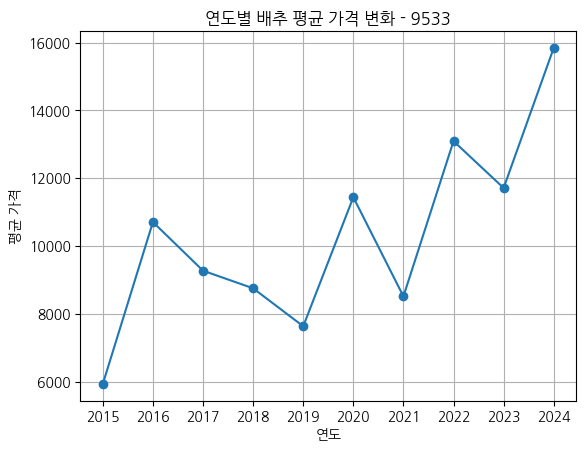

In [14]:
import matplotlib.pyplot as plt

plt.plot(year_avg.index, year_avg.values, marker="o")

plt.title("연도별 배추 평균 가격 변화 - 9533")
plt.xlabel("연도")
plt.ylabel("평균 가격")
plt.xticks(year_avg.index)

plt.grid()
plt.savefig("연도별_배추_평균가격_9533.png")
plt.show()

In [15]:
season_avg = df.groupby("season")["exmn_dd_prc"].mean()

season_avg = season_avg.reindex(["봄", "여름", "가을", "겨울"])

print(season_avg)

season
봄      9497.681159
여름    11121.329305
가을    12928.134557
겨울     7571.786834
Name: exmn_dd_prc, dtype: float64


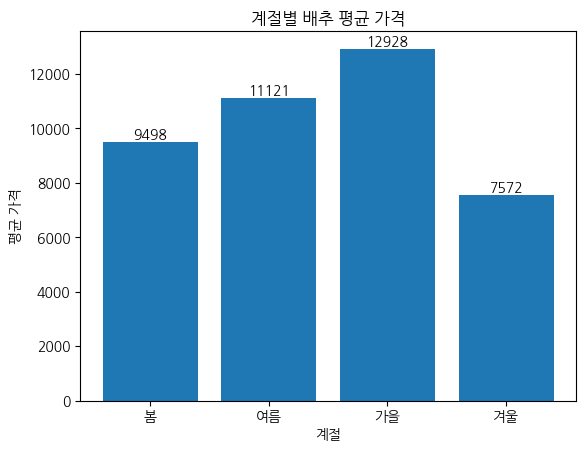

In [17]:
bars = plt.bar(season_avg.index, season_avg.values)

plt.title("계절별 배추 평균 가격")
plt.xlabel("계절")
plt.ylabel("평균 가격")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom"
    )
plt.savefig("계절별_배추_평균가격.png")
plt.show()